In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Flatten, Input, Activation
from tensorflow.keras.layers import Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

In [2]:
import numpy as np
from pathlib import Path
import pandas as pd

In [3]:
import sys
sys.path.append("..")
from dataset import make_sr_dataset
import matplotlib.pyplot as plt

2.18.1


In [4]:
#Učitavanje skupa podataka, pravljenje string liste i postavljanje nasumičnog semeta radi reproduktabilnosti
ROOT = Path("../data/raw/Flickr2K")
path = [str(p) for p in ROOT.glob('*.png')]


np.random.seed(7)
np.random.shuffle(path)

In [5]:
#Globalne promenljive
HR_SIZE = 128
SCALE = 2
LR_SIZE = 64
BATCH = 8
EPOCHS = 10

In [9]:
#pravljenje test tenzora 
test_paths = path[2120+265 :]
ds_test = make_sr_dataset(test_paths,HR_SIZE,SCALE,BATCH,False)
lr,hr = next(iter(ds_test))

In [10]:
model_paths = {
    "base_autoencoder": "../models/sr_autoencoder.keras",
    "smaller_autoencoder": "../models/best_model_smaller.keras",
    "bigger_autoencoder": "../models/best_model_bigger.keras",
}

In [12]:
results = []

for model_name, model_path in model_paths.items():
    print(f"\nEvaluating: {model_name}")
    
    model = tf.keras.models.load_model(model_path, compile=False)

    psnr_scores = []
    ssim_scores = []
    mae_scores = []

    for lr, hr in ds_test:
        pred = model(lr, training=False)
        pred = tf.clip_by_value(pred, 0.0, 1.0)

        psnr_batch = tf.image.psnr(hr, pred, max_val=1.0)
        ssim_batch = tf.image.ssim(hr, pred, max_val=1.0)
        mae_batch = tf.reduce_mean(tf.abs(hr - pred), axis=[1, 2, 3])

        psnr_scores.extend(psnr_batch.numpy())
        ssim_scores.extend(ssim_batch.numpy())
        mae_scores.extend(mae_batch.numpy())

    results.append({
        "model": model_name,
        "PSNR_mean": float(np.mean(psnr_scores)),
        "SSIM_mean": float(np.mean(ssim_scores)),
        "MAE_mean": float(np.mean(mae_scores)),
    })


Evaluating: base_autoencoder


2026-03-11 13:14:28.598276: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Evaluating: smaller_autoencoder

Evaluating: bigger_autoencoder


In [13]:

# Bicubic baseline
psnr_scores = []
ssim_scores = []
mae_scores = []

for lr, hr in ds_test:
    lr_up = tf.image.resize(lr, (tf.shape(hr)[1], tf.shape(hr)[2]), method="bicubic")
    lr_up = tf.clip_by_value(lr_up, 0.0, 1.0)

    psnr_batch = tf.image.psnr(hr, lr_up, max_val=1.0)
    ssim_batch = tf.image.ssim(hr, lr_up, max_val=1.0)
    mae_batch = tf.reduce_mean(tf.abs(hr - lr_up), axis=[1, 2, 3])

    psnr_scores.extend(psnr_batch.numpy())
    ssim_scores.extend(ssim_batch.numpy())
    mae_scores.extend(mae_batch.numpy())

results.append({
    "model": "bicubic_baseline",
    "PSNR_mean": float(np.mean(psnr_scores)),
    "SSIM_mean": float(np.mean(ssim_scores)),
    "MAE_mean": float(np.mean(mae_scores)),
})

In [14]:

# Tabela rezultata
df_results = pd.DataFrame(results)

# Veći PSNR i SSIM su bolji, manji MAE je bolji
df_results = df_results.sort_values(
    by=["PSNR_mean", "SSIM_mean", "MAE_mean"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\nFinal ranking:")
print(df_results)


Final ranking:
                 model  PSNR_mean  SSIM_mean  MAE_mean
0     bicubic_baseline  35.709095   0.913546  0.017941
1  smaller_autoencoder  24.548851   0.690039  0.049620
2     base_autoencoder  24.026711   0.614884  0.054694
3   bigger_autoencoder  23.686275   0.620008  0.057144


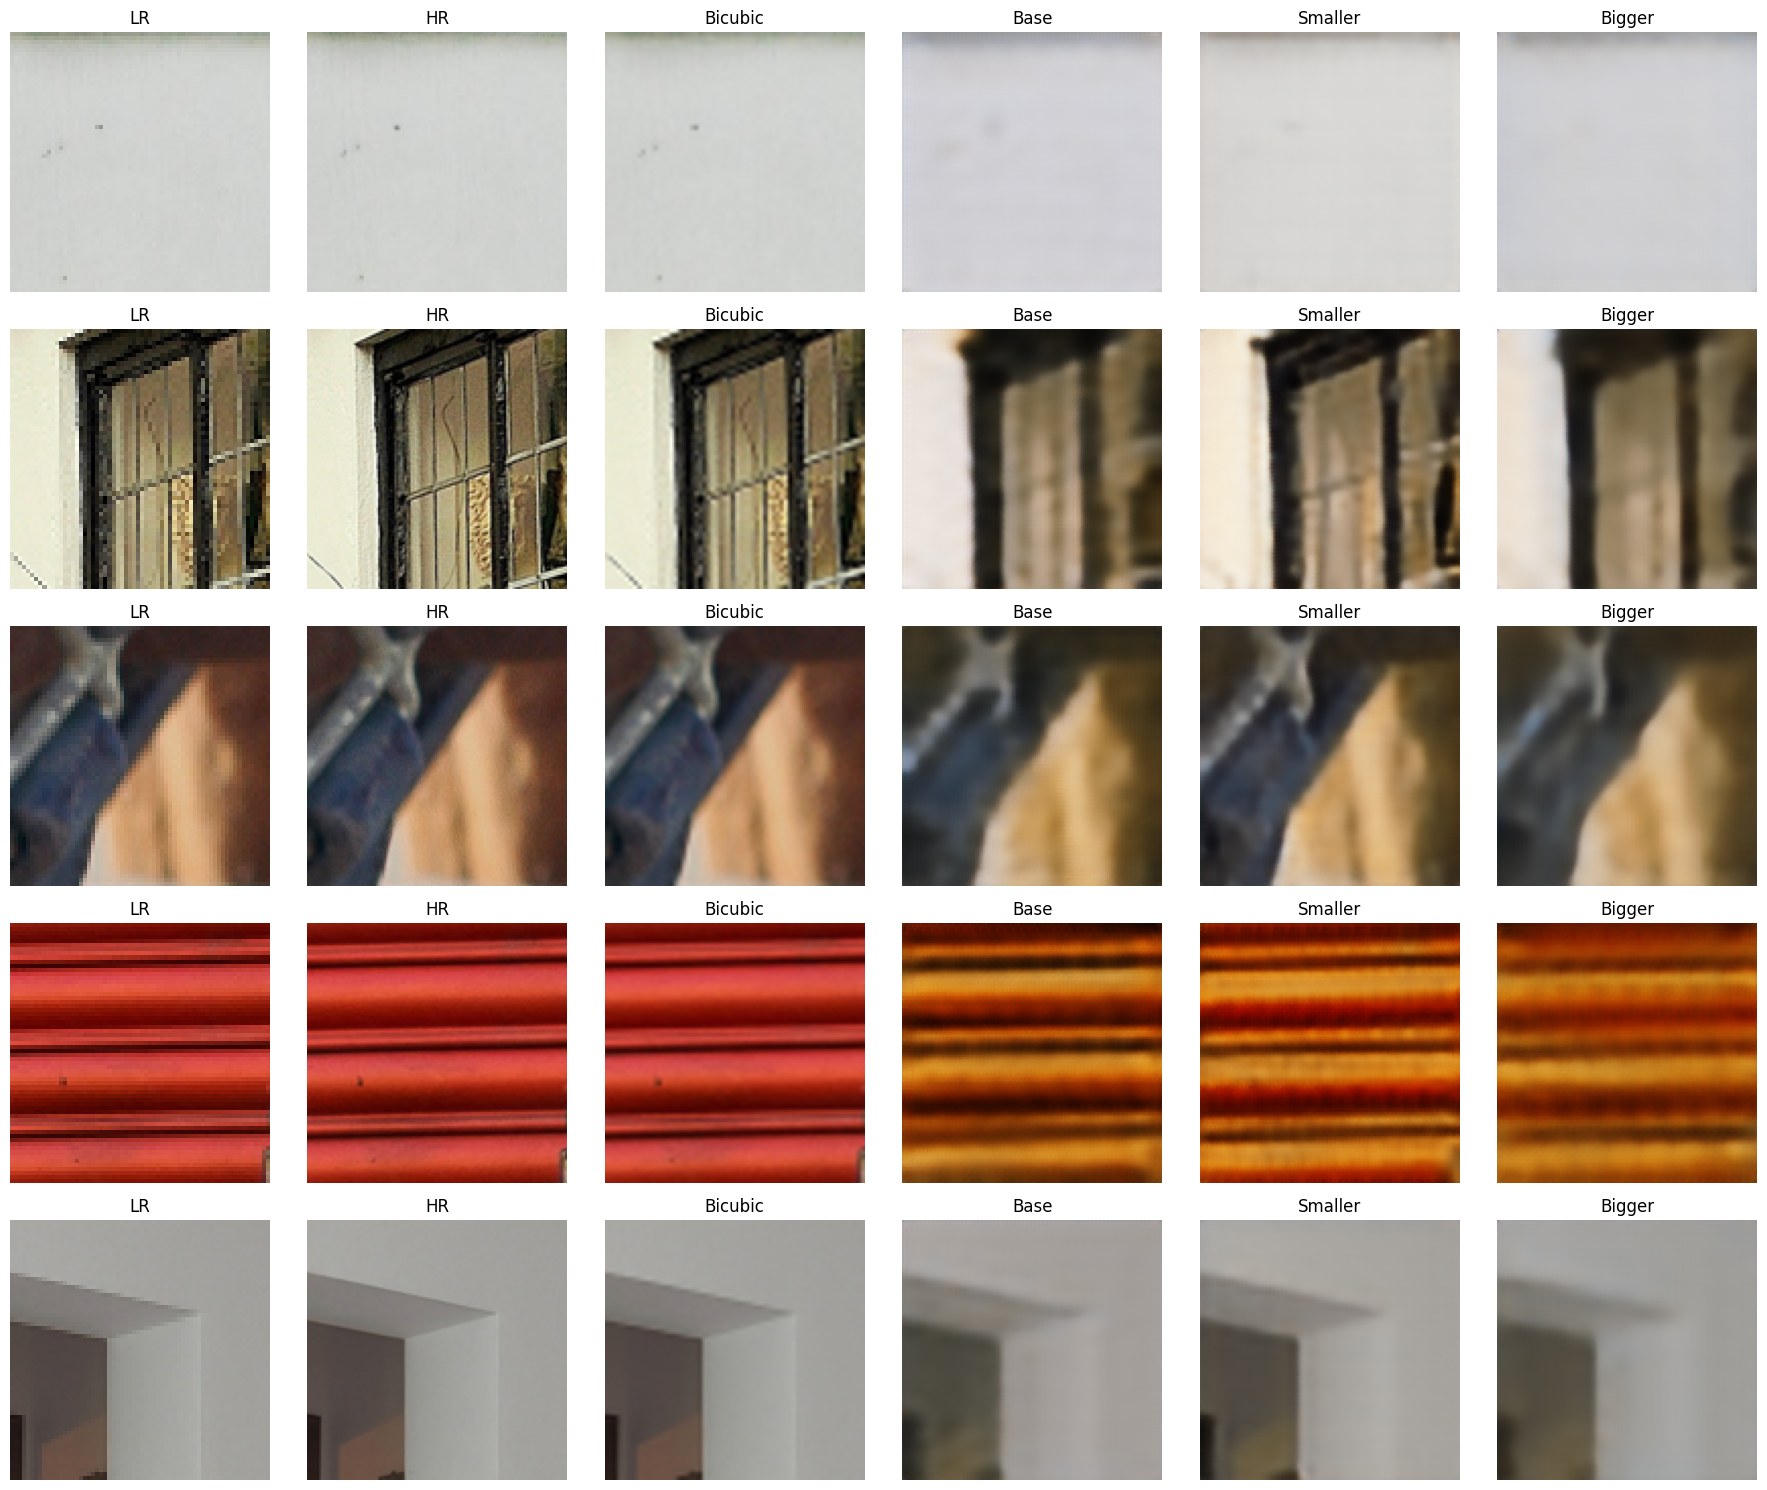

In [42]:
base_model = tf.keras.models.load_model("../models/sr_autoencoder.keras", compile=False)
smaller_model = tf.keras.models.load_model("../models/best_model_smaller.keras", compile=False)
bigger_model = tf.keras.models.load_model("../models/best_model_bigger.keras", compile=False)

num_images = 5  # koliko različitih slika 

for lr, hr in ds_test.skip(9).take(1):
    break

plt.figure(figsize=(18, 3*num_images))

for i in range(num_images):

    lr_img = lr[i:i+1]
    hr_img = hr[i]

    pred_base = tf.clip_by_value(base_model(lr_img, training=False)[0], 0.0, 1.0)
    pred_smaller = tf.clip_by_value(smaller_model(lr_img, training=False)[0], 0.0, 1.0)
    pred_bigger = tf.clip_by_value(bigger_model(lr_img, training=False)[0], 0.0, 1.0)

    bicubic = tf.image.resize(lr_img[0], (128,128), method="bicubic")
    bicubic = tf.clip_by_value(bicubic,0.0,1.0)

    # LR
    plt.subplot(num_images,6,i*6+1)
    plt.imshow(lr_img[0])
    plt.title("LR")
    plt.axis("off")

    # HR
    plt.subplot(num_images,6,i*6+2)
    plt.imshow(hr_img)
    plt.title("HR")
    plt.axis("off")

    # bicubic
    plt.subplot(num_images,6,i*6+3)
    plt.imshow(bicubic)
    plt.title("Bicubic")
    plt.axis("off")

    # base
    plt.subplot(num_images,6,i*6+4)
    plt.imshow(pred_base)
    plt.title("Base")
    plt.axis("off")

    # smaller
    plt.subplot(num_images,6,i*6+5)
    plt.imshow(pred_smaller)
    plt.title("Smaller")
    plt.axis("off")

    # bigger
    plt.subplot(num_images,6,i*6+6)
    plt.imshow(pred_bigger)
    plt.title("Bigger")
    plt.axis("off")

plt.tight_layout()
plt.show()